In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import norm

In this part, we will explore a dataset usually used in machine learning to perform classification. It has several demographic features of adults and a column that shows whether they have an income of atleast 50k. Of course, before performing machine learning we need to clean the dataset and visualise it so as to ascertain whether it will give reliable results.

**Question: ** Read the dataset `adults.csv` into the variable `adultsData`. `fnlwgt` is the index column.

In [15]:
#Write your code here
# connecting to google drive to get dataset

from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/ColabNotebooks/DA2/Part02/adults.csv'
adultsData = pd.read_csv(path)
adultsData.set_index('fnlwgt', inplace=True)

print(adultsData.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
        age  workclass     education  years of education      marital status  \
fnlwgt                                                                         
226802   25    Private          11th                   7       Never-married   
89814    38    Private       HS-grad                   9  Married-civ-spouse   
336951   28  Local-gov    Assoc-acdm                  12  Married-civ-spouse   
160323   44    Private  Some-college                  10  Married-civ-spouse   
103497   18    Private  Some-college                  10       Never-married   

               occupation relationship status   race  gender  capital gain  \
fnlwgt                                                                       
226802  Machine-op-inspct           Own-child  Black    Male             0   
89814     Farming-fishing             Husband  White    Male             0  

**Question: ** Convert all numerical columns, including the index, into the `int` datatype.

In [4]:
#Write your code here

#print(adultsData.dtypes)
numeric_Cols = adultsData.select_dtypes(include=['int64', 'float64']).columns

adultsData[numeric_Cols] = adultsData[numeric_Cols].astype(int)
adultsData.index = adultsData.index.astype(int)

adultsData.to_csv(path)

print(adultsData.index[:3])
print(adultsData.dtypes)



Index([226802, 89814, 336951], dtype='int64', name='fnlwgt')
age                     int64
workclass              object
education              object
years of education      int64
marital status         object
occupation             object
relationship status    object
race                   object
gender                 object
capital gain            int64
capital loss            int64
hours per week          int64
native country         object
capital-profit          int64
income                 object
dtype: object


**Question: ** Replace values in the `income` such that if `income <= 50k = 0` and `income > 50k = 1`.  

In [7]:
#Write your code here
adultsData['income'] = adultsData['income'].astype(str).str.strip()
adultsData['income'] = adultsData['income'].apply(lambda x: 0 if x == '<=50K' else 1)

print(adultsData['income'].value_counts())
print("\nWhere '0' if income is less than or equal to 50k and 1 otherwise.")

income
1    48842
Name: count, dtype: int64

Where '0' if income is less than or equal to 50k and 1 otherwise.


**Question: ** Change the name of the column `education-num` to `years of education` and `relationship` to `relationship status`. Replace dashes in the index names with spaces (without hardcoding).

In [8]:
# Renaming the columns
adultsData.rename(columns={'educational-num': 'years of education', 'relationship': 'relationship status'}, inplace=True)

# fixing column names and removing dashes
adultsData.columns = adultsData.columns.str.replace('-', ' ',regex= False)

# Removing dashes from index names
adultsData.index = adultsData.index.astype(str).str.replace('-', ' ',regex = False)

print(adultsData.columns.tolist())
print(adultsData.index[:3])



['age', 'workclass', 'education', 'years of education', 'marital status', 'occupation', 'relationship status', 'race', 'gender', 'capital gain', 'capital loss', 'hours per week', 'native country', 'capital profit', 'income']
Index(['226802', '89814', '336951'], dtype='object', name='fnlwgt')


**Question: ** Convert all the string columns into the `string` datatype.

In [ ]:
#Write your code here
adultsData = adultsData.apply(lambda x: x.astype('string') if x.dtype == 'object' else x)
print(adultsData.dtypes)

age                             int64
workclass              string[python]
education              string[python]
years of education              int64
marital-status         string[python]
occupation             string[python]
relationship status    string[python]
race                   string[python]
gender                 string[python]
capital-gain                    int64
capital-loss                    int64
hours-per-week                  int64
native-country         string[python]
income                          int64
dtype: object


**Question: ** Write a function `dashToSpace` that receives an entire column of a dataframe and returns a copy of the column with dashes replaced with spaces.

In [ ]:
#Write your code here

#function to convert dashes to spaces in all cells
#function declaration

def dashToSpace(col, inplace = False):
  return adultsData.map(lambda x: x.replace('-', ' ') if isinstance(x, str) else x)

#function call
adultsData_clean = dashToSpace(adultsData)

print(adultsData_clean.head())

        age  workclass     education  years of education      marital-status  \
fnlwgt                                                                         
226802   25    Private          11th                   7       Never married   
89814    38    Private       HS grad                   9  Married civ spouse   
336951   28  Local gov    Assoc acdm                  12  Married civ spouse   
160323   44    Private  Some college                  10  Married civ spouse   
103497   18       <NA>  Some college                  10       Never married   

               occupation relationship status   race  gender  capital-gain  \
fnlwgt                                                                       
226802  Machine op inspct           Own child  Black    Male             0   
89814     Farming fishing             Husband  White    Male             0   
336951    Protective serv             Husband  White    Male             0   
160323  Machine op inspct             Husband  Bl

**Question: ** Use the function `dashtoSpace` inplace on `adultsData`.

In [ ]:
#Write your code here
# using function dashToSpace inplace on adultData
adultsData = dashToSpace(adultsData, inplace = True)
print(adultsData.head())



        age  workclass     education  years of education      marital-status  \
fnlwgt                                                                         
226802   25    Private          11th                   7       Never married   
89814    38    Private       HS grad                   9  Married civ spouse   
336951   28  Local gov    Assoc acdm                  12  Married civ spouse   
160323   44    Private  Some college                  10  Married civ spouse   
103497   18       <NA>  Some college                  10       Never married   

               occupation relationship status   race  gender  capital-gain  \
fnlwgt                                                                       
226802  Machine op inspct           Own child  Black    Male             0   
89814     Farming fishing             Husband  White    Male             0   
336951    Protective serv             Husband  White    Male             0   
160323  Machine op inspct             Husband  Bl

**Question: ** Visualize total number of missing values for columns that contain missing values. Only plot the columns which have missing values. Choose a suitable visualization.  

workclass         2799
occupation        2809
native country     857
dtype: int64


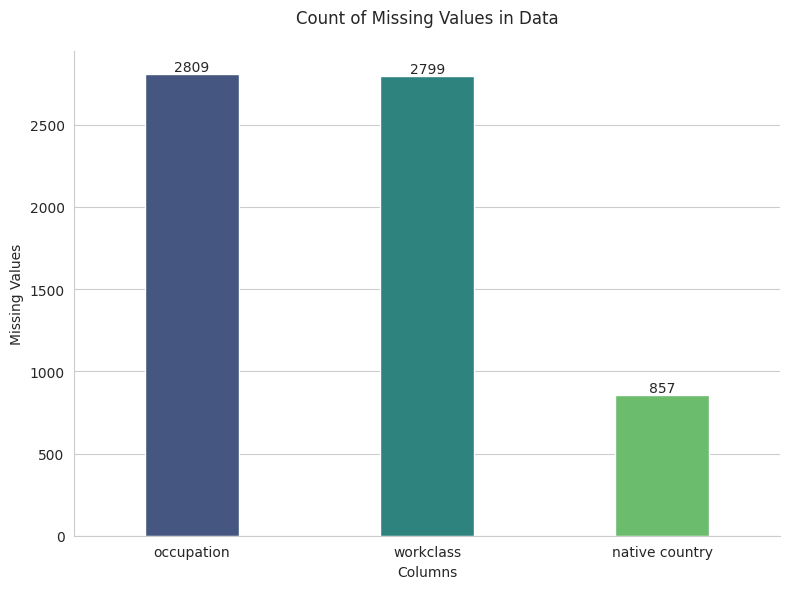

In [ ]:
#Write your code here

# finding columns with missing values and counting those values for columns

missing_cols = adultsData.columns[adultsData.isnull().any()]
missing_counts = adultsData[missing_cols].isnull().sum()
print(missing_counts)

# converting values to dataframe to draw visualization
missing_data = pd.DataFrame({'Column': missing_counts.index, 'Missing Values': missing_counts.values}).sort_values(by='Missing Values', ascending=False)

# figure charecteristics using seaborn
set_style = sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.barplot(x='Column', y='Missing Values', data=missing_data, hue = 'Column', palette = 'viridis',width = 0.4, legend = False)

# for labels on bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='bottom')

plt.title("Count of Missing Values in Data",pad=20, )
plt.xlabel("Columns")
plt.ylabel("Missing Values")

#plt.xticks(rotation=9, ha='right')
plt.tight_layout()
sns.despine()

plt.show()

#print(missing_data)


**Question: ** In this question we will deal with null values. Replace the null values in each column with the non-null categorical mode of the column with the years of education. What that means is for each unique value of `years of education` find the mode of column's non-null rows. Use loops if you wish.

In [ ]:
#  for each unique value of 'years of education' find mode of col's non null rows and replace null values in each col with that mode

#group wise mode calculation
for i in adultsData['years of education'].unique():
  subset = adultsData[adultsData['years of education'] == i]
  mode_value = subset.mode().iloc[0]

# replacing nulls with mode value
  for col in adultsData.select_dtypes(include='object').columns:
    adultsData.loc[adultsData[col].isnull() & (adultsData['years of education'] == i), col] = mode_value[col]

print(adultsData.isnull().sum())

age                    0
workclass              0
education              0
years of education     0
marital status         0
occupation             0
relationship status    0
race                   0
gender                 0
capital gain           0
capital loss           0
hours per week         0
native country         0
income                 0
dtype: int64


**Question: ** Combine `capital gain` and `capital loss` columns into `capital profit`. Insert `capital profit` into `adultsData` right before `income`.

In [ ]:
# making a new column capital profit by combining capital gain and capital loss and place that col in dataset just before income column

adultsData.insert(adultsData.columns.get_loc('income'), 'capital-profit', adultsData['capital gain'] - adultsData['capital loss'])

#adultsData = adultsData.drop(['capital profit'], axis =1)

print(adultsData.info())


<class 'pandas.core.frame.DataFrame'>
Index: 48842 entries, 226802 to 287927
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  48842 non-null  int64 
 1   workclass            48842 non-null  object
 2   education            48842 non-null  object
 3   years of education   48842 non-null  int64 
 4   marital status       48842 non-null  object
 5   occupation           48842 non-null  object
 6   relationship status  48842 non-null  object
 7   race                 48842 non-null  object
 8   gender               48842 non-null  object
 9   capital gain         48842 non-null  int64 
 10  capital loss         48842 non-null  int64 
 11  hours per week       48842 non-null  int64 
 12  native country       48842 non-null  object
 13  capital-profit       48842 non-null  int64 
 14  income               48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 6.0+ MB
None


**Question: ** Display a colored correlation heatmap for all numerical columns in `adultsData`. Format the heatmap as follows:
- Display correlation values on the heatmap
- Use a diverging color palette of your choice

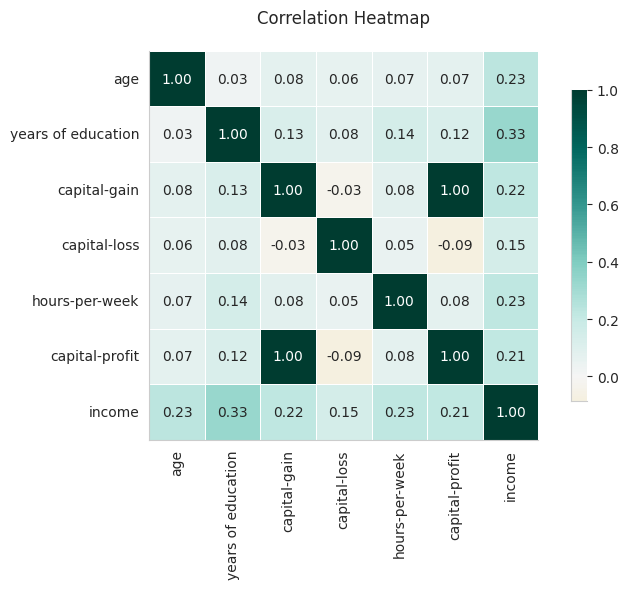

In [ ]:
# finding all numeric columns and their correlation
numeric_Cols = adultsData.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = adultsData[numeric_Cols].corr()

# figure charecteristics using seaborn
set_style = sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))

# setting up heatmap
sns.heatmap(correlation_matrix,
            annot = True,
            fmt ='.2f',
            cmap = 'BrBG',
            center = 0,
            square = True,
            linewidths = 0.5,
            cbar_kws = {'shrink': 0.8}
)
plt.title('Correlation Heatmap', pad=20)

plt.tight_layout()
sns.despine()

plt.show()


**Question: ** Describe what the heatmap shows.

**In heat maps usually:**

    +1 --> +0.5 show strong correlation.
    ~~ 0 shows weak or no correlation.
    -0.5 --> -1 shows strong negative correlation.

**From above heatmap we can see:**

**Most Positive Correlation between : **

                          : years of education & income
                           : age and income.
                           : capital gain, income.
                           : capital profit and income.

**Weak Positive Correlation between :**

                              : age and years of education.
                                  
**Negative correlation between :**
                            
                             : capital gain and capital loss.
                             : capital profit and capital loss.

Most relationships are weak in dataset.


**Conclusion:**

It can be said that older people tend to have smewhat higher income levels.

   Higher education also plays some role in higher income levels.

   Older people not necessarily have to have higher education levels as well.

   There is no correlation between capital gain and capital loss or capital profit and capital loss. These variables are statistically independent of others.

**Question: ** For all numerical columns in `adultsData`, plot their relationships with average income. Use a suitable representation. You can use for loops here.

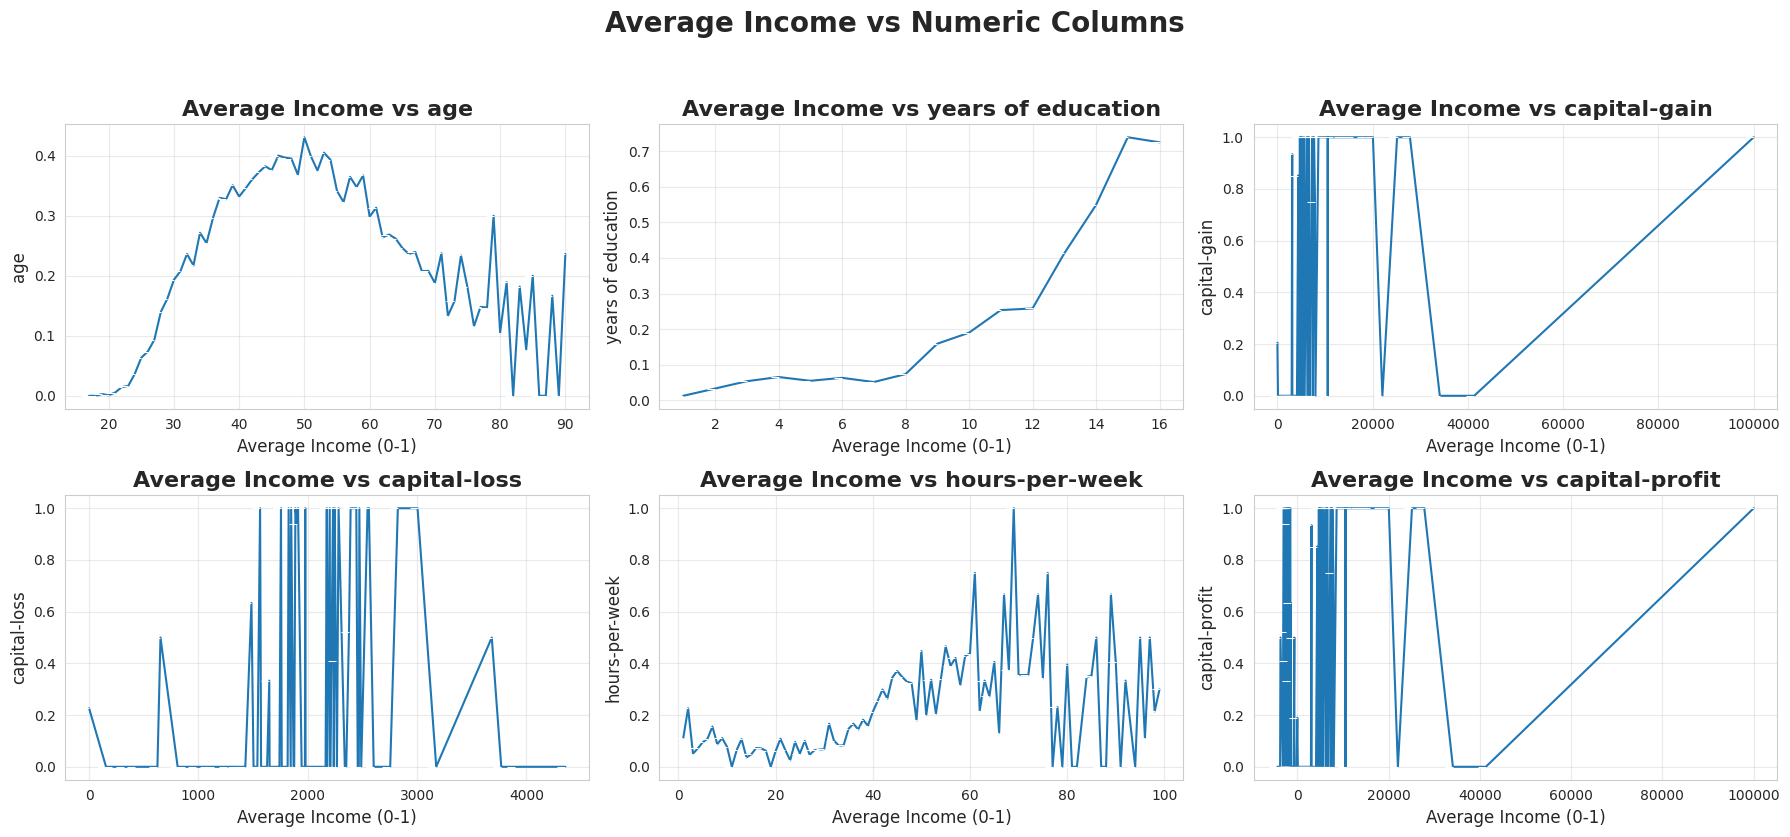

In [ ]:
# plotting relationship of numerical columns with average income.
#print(adultsData.info())

numeric_cols = adultsData.select_dtypes(include=['int64', 'float64']).columns     # finding numerical columns only

numeric_cols = numeric_cols.drop('income')    #excluding income column

#print(numeric_Cols)

#loop through numeric columns and plot
# auto calculate layout for sub plots
n = len(numeric_cols)
cols =  3
rows = int(np.ceil(n / cols))
sns.set_style('whitegrid')
plt.figure(figsize=(6 * cols, 4 * rows))
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(numeric_cols,1):

  plt.subplot(rows, cols , i)

  average_income = adultsData.groupby(col)['income'].mean().reset_index().sort_values(by=col)

  sns.lineplot(data = average_income, x= col, y= 'income', marker = 0)

  plt.title(f'Average Income vs {col}', fontsize = 16, weight = 'bold')

  plt.xlabel('Average Income (0-1)',fontsize = 12)
  plt.ylabel(col, fontsize = 12)
  plt.grid(alpha=0.4)
  #plt.tight_layout()

  plt.suptitle('Average Income vs Numeric Columns', fontsize = 20, weight = 'bold', y = 1.04)

  plt.tight_layout()
plt.show()

**Question: ** For each numerical columns in `adultData`, draw a scatter plot with <b>all</b> other numerical columns with distinct values of the numerical column on the x-axis and the average value of numerical columns on the y-axis. For example, `age` against `average years of education`. You can use for loops here.

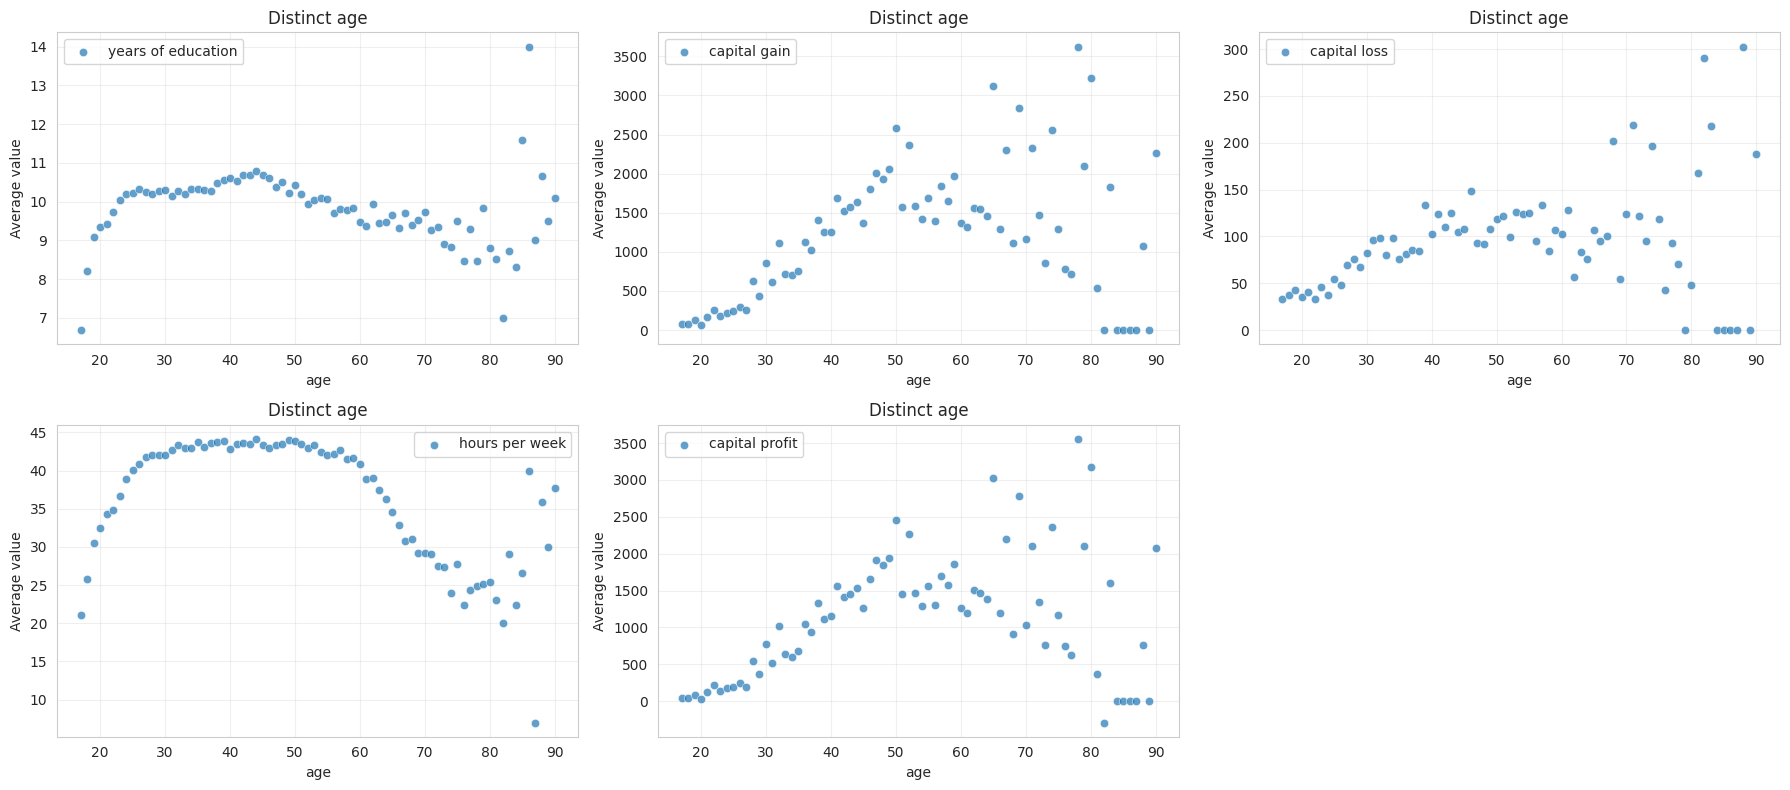

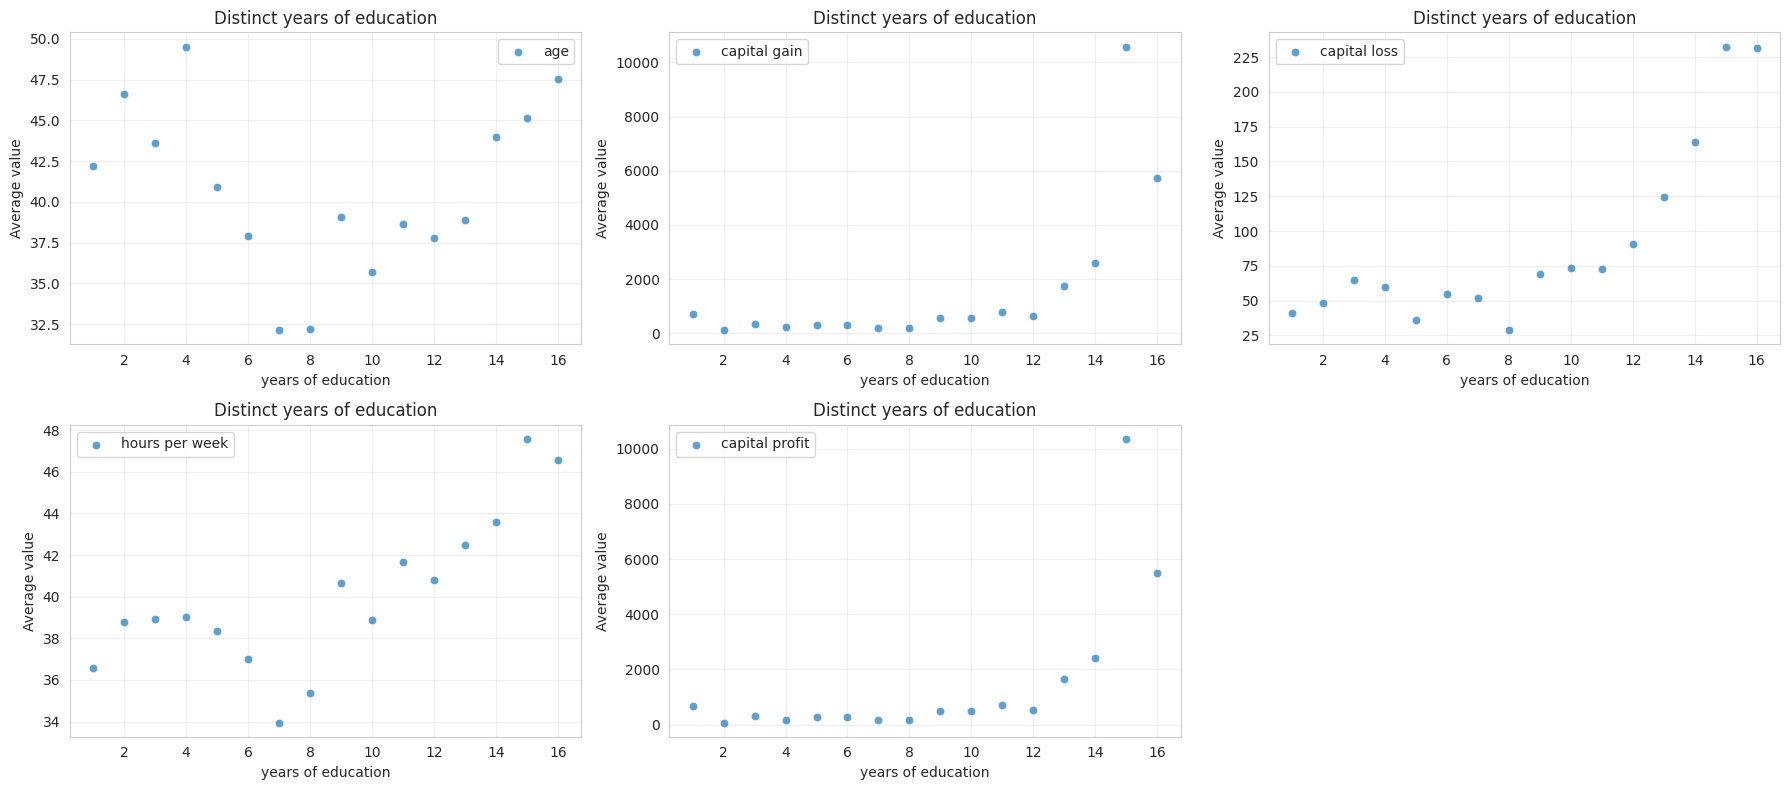

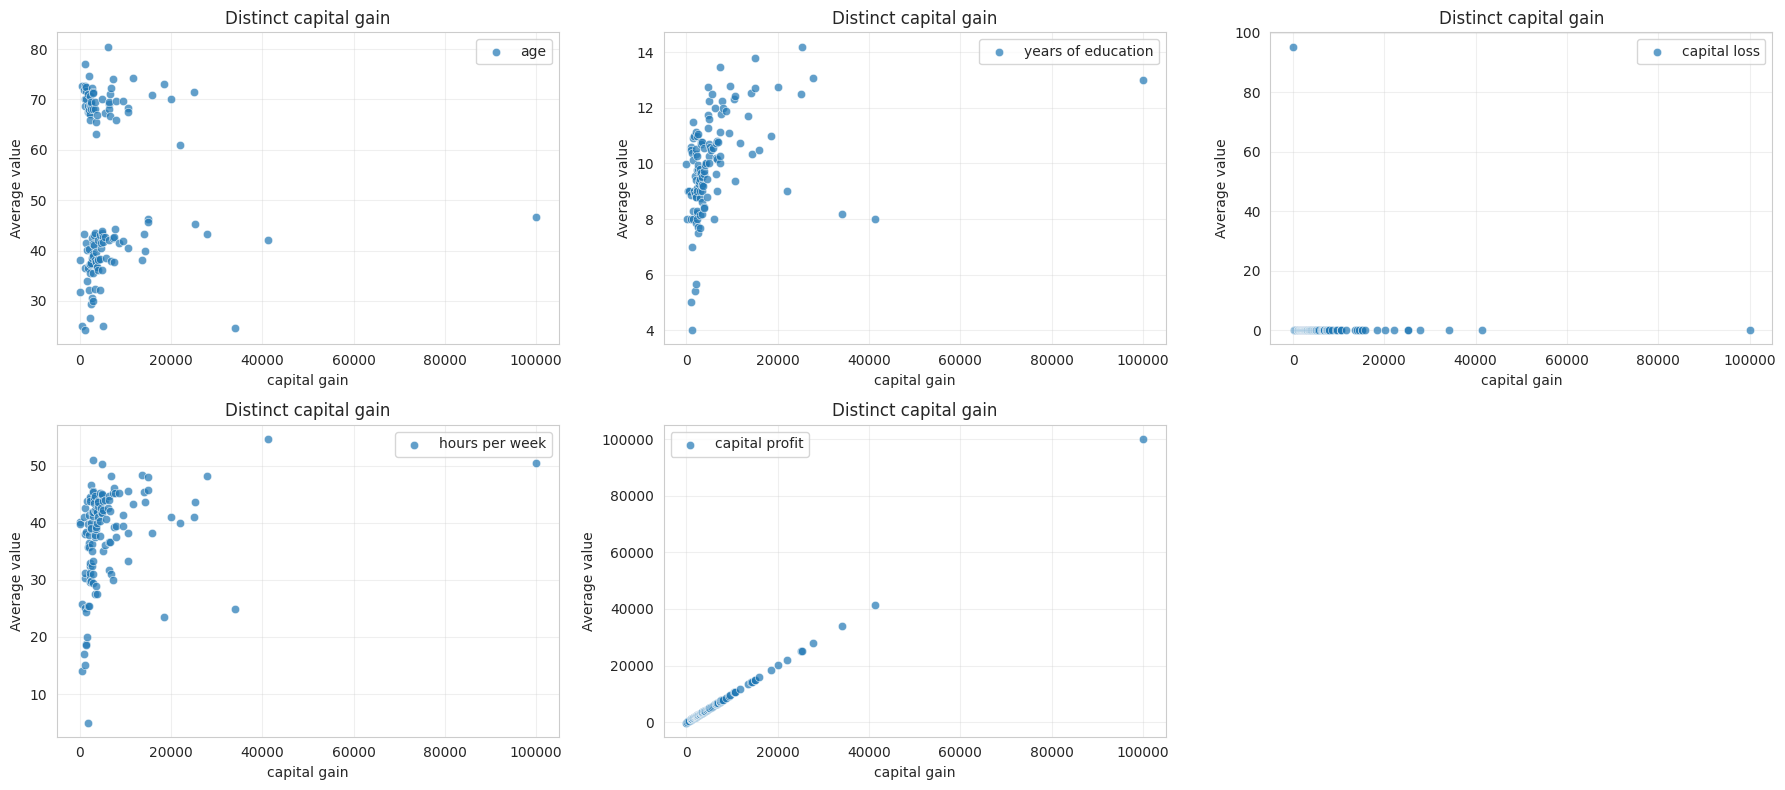

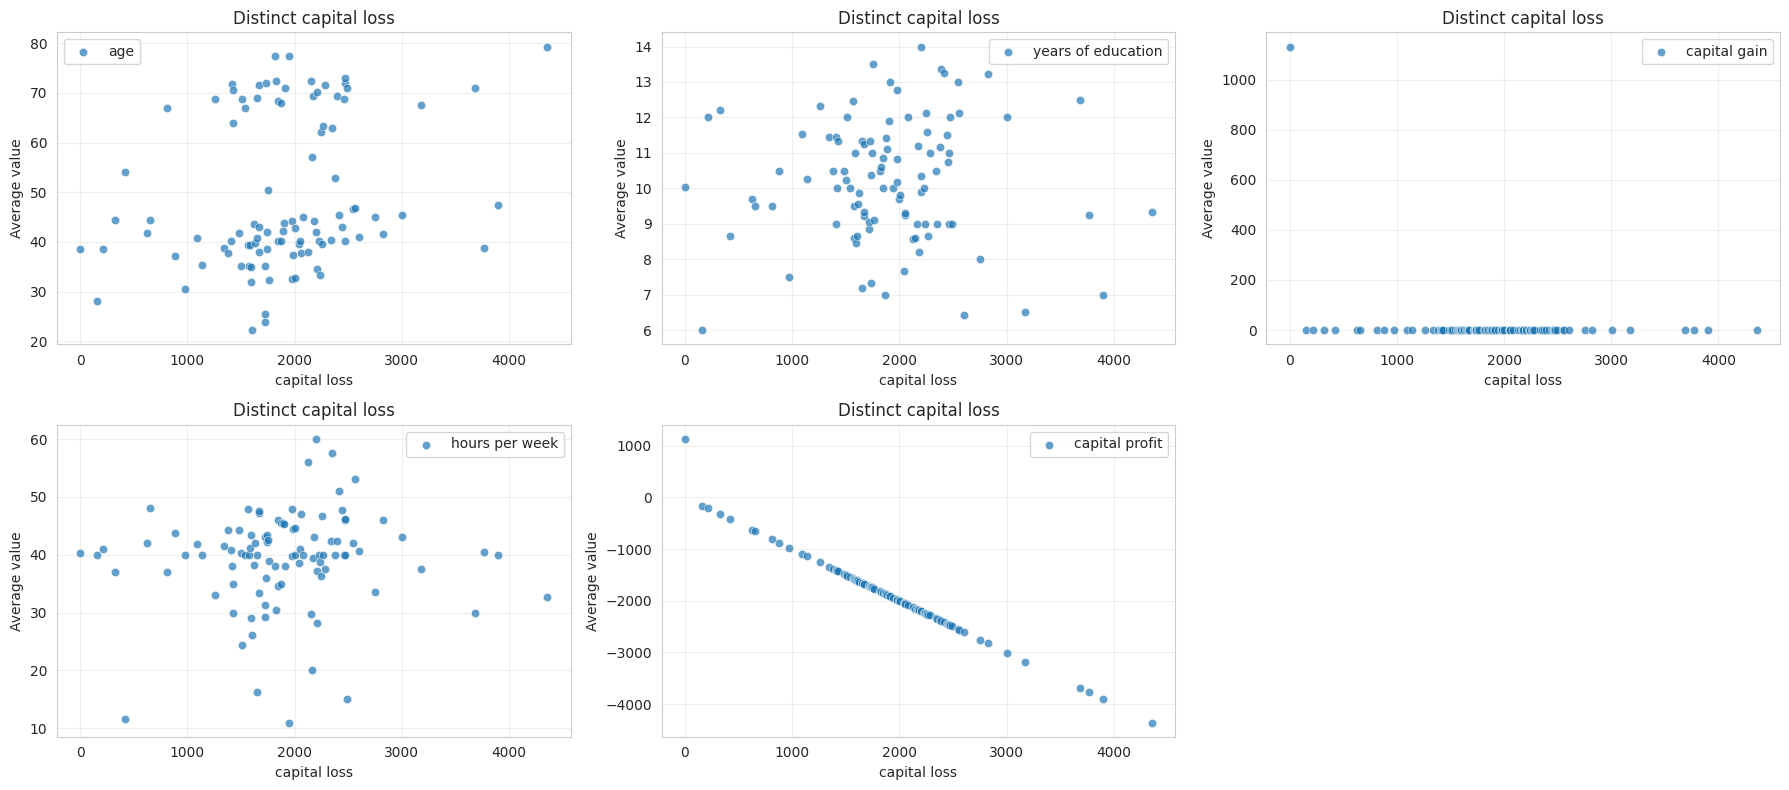

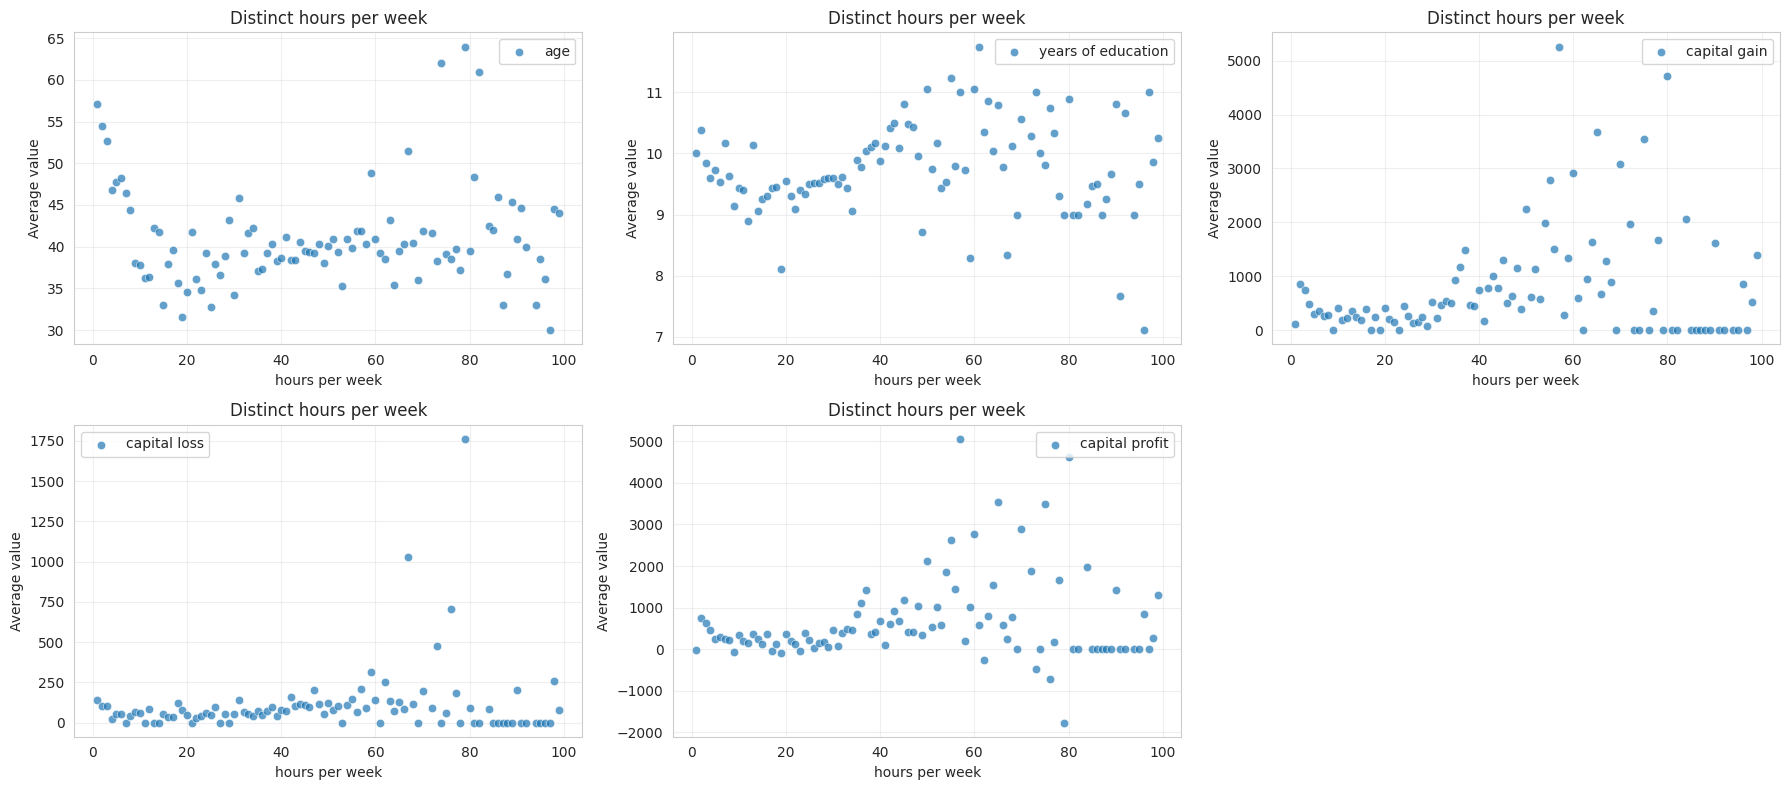

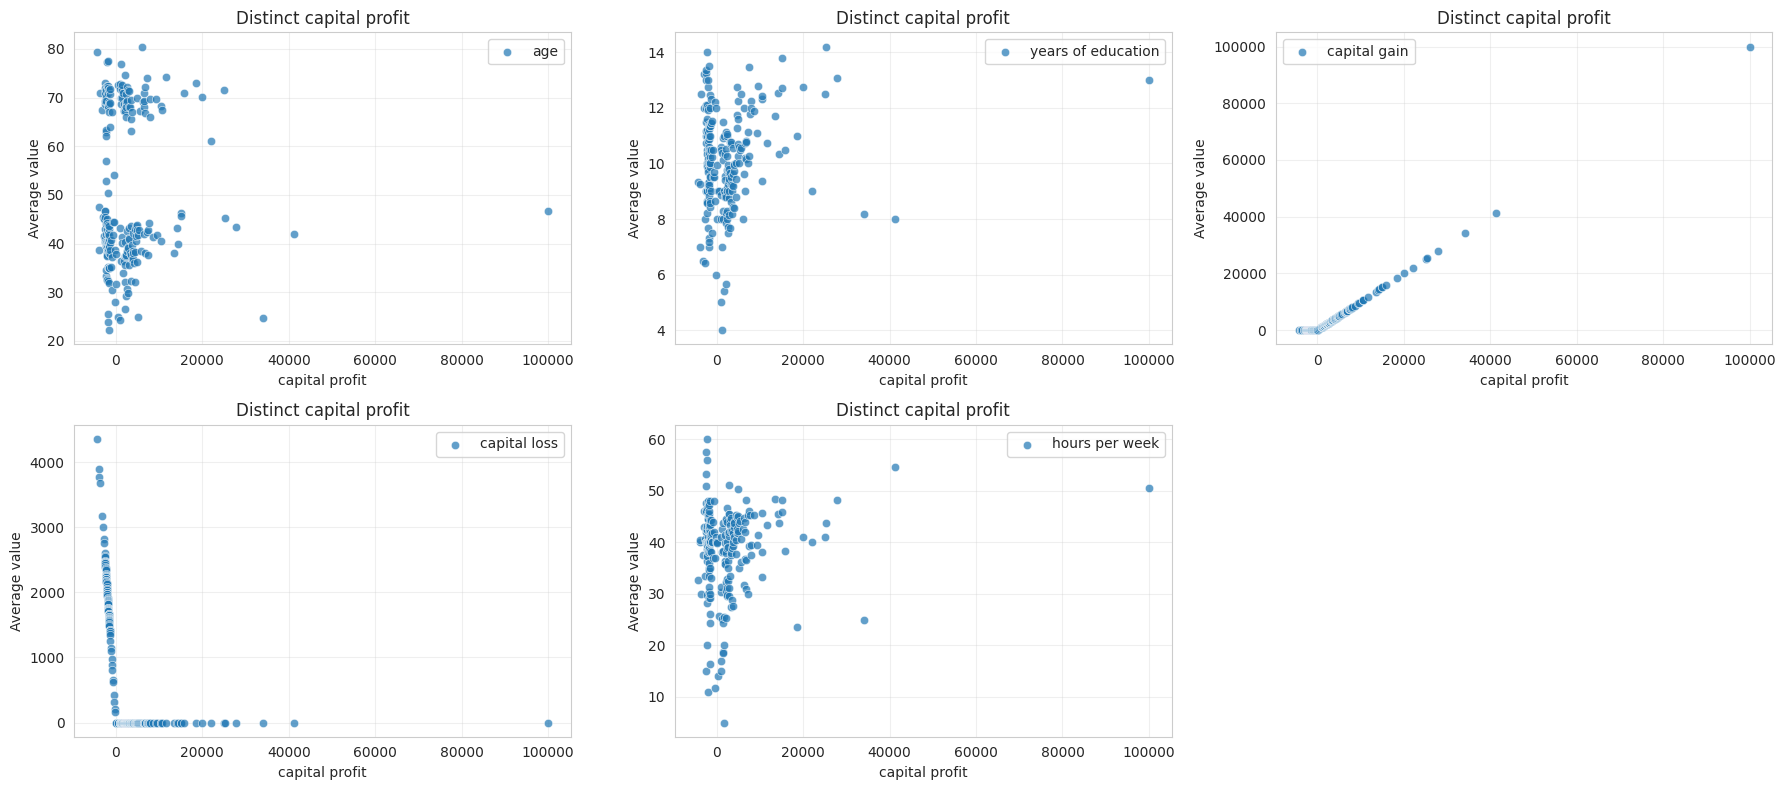

In [ ]:
# Find distinct values of numerical columns
# we already have list of number columns that is numeric_cols
# for each distinct numeric column at x, getting average of all other numeric columns at y axis in different graphs for each

for x_col in numeric_cols:
  other_cols = [col for col in numeric_cols if col != x_col]

  if not other_cols:
    continue

  n = len(numeric_cols)
  cols = 3
  rows = int(np.ceil( n/cols))

  sns.set_style('whitegrid')
  plt.figure(figsize=(6 * cols, 4 * rows))

  for i, col in enumerate(other_cols, 1):
    ax = plt.subplot(rows, cols, i)
    grouped_cols = (adultsData.groupby(x_col)[col].mean().reset_index())
    sns.scatterplot(data=grouped_cols, x=x_col, y=col, label=col, alpha=0.7)
    plt.title(f'Distinct {x_col}')
    plt.xlabel(x_col)
    plt.ylabel('Average value')
    plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()


**Question: ** For all non-numerical columns in `adultsData`, plot their relationships with average income. Use a suitable representation. You can use for loops here.

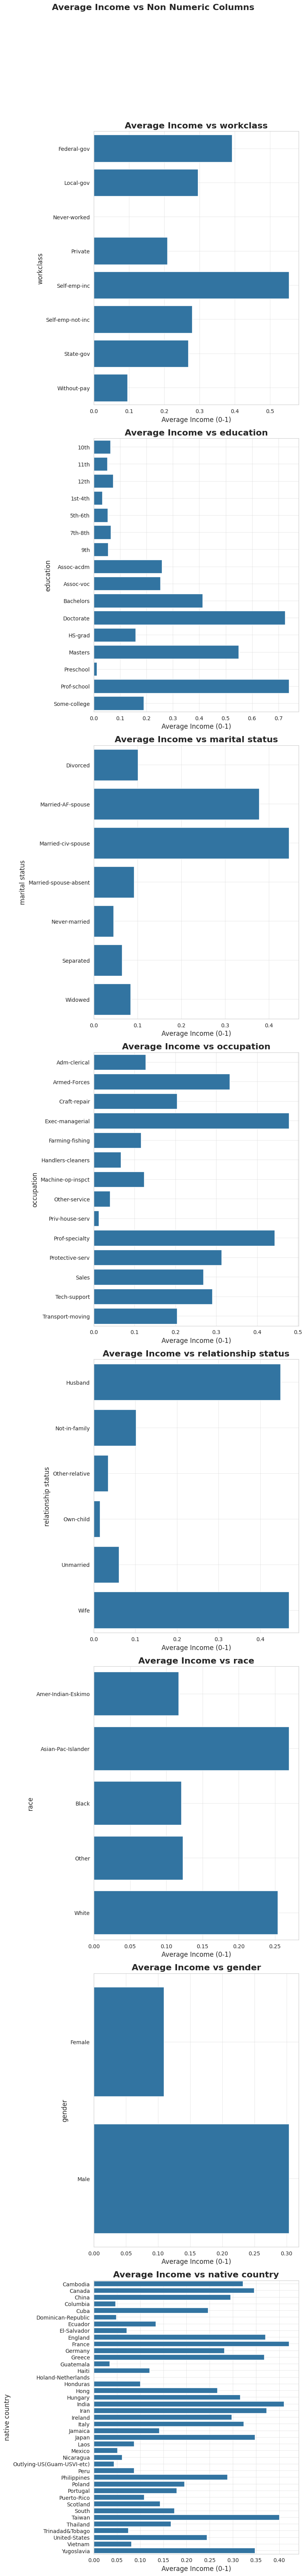

In [ ]:
# selecting all non-numerical columns
non_numeric_cols = adultsData.select_dtypes(exclude=[np.number]).columns.tolist()

n = len(non_numeric_cols)
cols =  1
rows = int(np.ceil(n / cols))
sns.set_style('whitegrid')

plt.figure(figsize=(8 * cols, 8 * rows))
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(non_numeric_cols,1):

  plt.subplot(rows, cols , i)

  average_income = adultsData.groupby(col)['income'].mean().reset_index().sort_values(by=col)

  sns.barplot(data = average_income, x= 'income', y= col)

  plt.title(f'Average Income vs {col}', fontsize = 16, weight = 'bold')

  plt.xlabel('Average Income (0-1)',fontsize = 12)
  plt.ylabel(col, fontsize = 12)
  plt.grid(alpha=0.4)
  #plt.tight_layout()

  plt.suptitle('Average Income vs Non Numeric Columns', fontsize = 16, weight = 'bold', y = 1.04)

  plt.tight_layout()

plt.show()


Due to lack of time could not produce better visualization. Bars widths and graphs width could be auto set. But due to less time available to complete assignment, could not do so

**Question: ** Describe the relation of each non-numerical column with the income as you see in the above plots. Specifically describe what effect being in a certain category has on the income

In [ ]:
# print non numeric cols only
print(non_numeric_cols)


['workclass', 'education', 'marital-status', 'occupation', 'relationship status', 'race', 'gender', 'native-country']


***Relation of Each Non-Numerocal column With Income in Above Plots***



***Income vs Education***

Education has strong relation with Income.
•	It’s very evident that people who have professional school education or having doctorate degrees are earning far better than other education levels.  
•	At second place master’s degree holders and then bachelor’s degree holders are earning better.
•	Strong relation of better education, better earning.

***Income vs Occupation***

•	Executive managerial posts produce best earnings. Usually, people with higher education, and sound professional capabilities at senior levels reach these posts.
•	Secondly, people with professional specialties are earning better
•	Thirdly people from Armed Forces are earning better.

***Income vs Work Class***

•	Self-employed incorporated people are earning better as compared to non-incorporated people.
•	Secondly Federal govt employees have better income.
•	Thirdly, people from local government are receiving better income.

***Income vs Marital Status***

•	First place married people with civilian spouses are earning really good
•	At second place are people who are married and have armed forces spouses.
•	Thirdly there are people who are divorced.
This clearly shows that households having two earning hands are getting better income.

***Income vs Relationship***

•	Wives earn most, husbands moderate, own child, not in family and un married the lowest.
•	Family roles align strongly with most earner patterns.
Income vs Race  
•	Asian Pacific Islanders and white are getting better income
•	Black, Amer-Indian and other categories are getting comparatively lower income
It shows socioeconomic inequalities exist

***Income vs gender***

Males are getting substantially higher income than females
It shows some biasedness as in spite of fact of similar working hours, females are paid less

***Income vs Native Country***

•	France, India and Taiwan are top three countries respectively, where people have better average income
